In [7]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import json
import torch.nn.functional as F

# Detect device — will use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


[HAMI-core Msg(141:139765956377920:libvgpu.c:855)]: Initialized


In [8]:
# ── Hyperparameter (Person 2 can tune this) ────────────────────────────────
BATCH_SIZE = 64
# ───────────────────────────────────────────────────────────────────────────

# Standard CIFAR-10 per-channel mean and std
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

# Transforms — Person 2 can extend train_transform with augmentation
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

# Download and load datasets
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform
)

# Create DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f'Training samples : {len(train_dataset)}')
print(f'Test samples     : {len(test_dataset)}')
print(f'Training batches : {len(train_loader)}')
print(f'Test batches     : {len(test_loader)}')

Training samples : 50000
Test samples     : 10000
Training batches : 782
Test batches     : 157


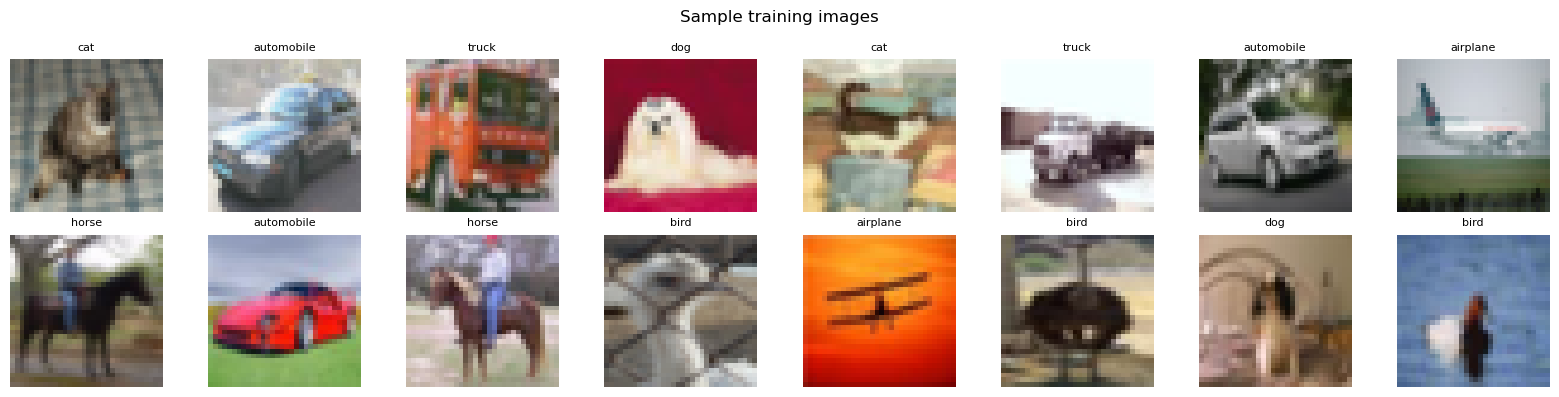

Image batch shape : torch.Size([64, 3, 32, 32])
Label batch shape : torch.Size([64])


In [9]:
def denormalise(tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    """Reverse normalisation for display purposes."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std  = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    img = denormalise(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample training images', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Image batch shape : {images.shape}')   # Expected: (64, 3, 32, 32)
print(f'Label batch shape : {labels.shape}')   # Expected: (64,)

In [10]:
class IntermediateBlock(nn.Module):
    """
    Intermediate block as described in Section 1.2.1.

    Takes image x of shape (B, in_channels, H, W) and outputs
    image x' of shape (B, out_channels, H, W) computed as a
    learned weighted sum of L independent parallel conv outputs.

    Args:
        in_channels     : number of input channels
        out_channels    : number of output channels per conv layer
        num_conv_layers : number of independent parallel conv layers (L)
        kernel_size     : conv kernel size (default 3)
    """

    def __init__(self, in_channels, out_channels, num_conv_layers, kernel_size=3):
        super().__init__()

        self.num_conv_layers = num_conv_layers

        # L independent parallel conv layers.
        # padding = kernel_size // 2 preserves H and W through the block.
        self.conv_layers = nn.ModuleList([
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                padding=kernel_size // 2
            )
            for _ in range(num_conv_layers)
        ])

        # FC layer:
        #   input  -> channel average of x  (in_channels dims)
        #   output -> L weights, one per conv layer
        self.fc = nn.Linear(in_channels, num_conv_layers)

    def forward(self, x):
        """
        Args:
            x : tensor of shape (B, C, H, W)
        Returns:
            x_prime : tensor of shape (B, out_channels, H, W)
        """
        # Step 1: channel-wise spatial average -> m of shape (B, C)
        m = x.mean(dim=[2, 3])

        # Step 2: FC layer -> weighting vector a of shape (B, L)
        a = self.fc(m)

        # Step 3: run all L conv layers on the same input x
        # ReLU applied after each conv to introduce non-linearity.
        # Without this, stacked blocks collapse to a single linear transform.
        conv_outputs = [F.relu(conv(x)) for conv in self.conv_layers]
        # Each output: (B, out_channels, H, W)

        # Step 4: stack -> (B, L, out_channels, H, W)
        stack = torch.stack(conv_outputs, dim=1)

        # Step 5: reshape a for broadcasting -> (B, L, 1, 1, 1)
        a = a.view(a.size(0), self.num_conv_layers, 1, 1, 1)

        # Step 6: weighted sum over L -> (B, out_channels, H, W)
        x_prime = (stack * a).sum(dim=1)

        return x_prime

In [11]:
class OutputBlock(nn.Module):
    """
    Output block as described in Section 1.2.2.

    Takes image x of shape (B, C, H, W), computes channel-wise
    average, then passes through FC layer(s) to produce logits
    of shape (B, num_classes).

    Args:
        in_channels : number of input channels
        num_classes : number of output classes (10 for CIFAR-10)
        hidden_dim  : optional hidden layer size (None = single FC layer)
    """

    def __init__(self, in_channels, num_classes=10, hidden_dim=None):
        super().__init__()

        if hidden_dim is not None:
            # Two FC layers with ReLU — Person 2 can experiment with this
            self.fc = nn.Sequential(
                nn.Linear(in_channels, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, num_classes)
            )
        else:
            # Single FC layer — default baseline
            self.fc = nn.Linear(in_channels, num_classes)

    def forward(self, x):
        """
        Args:
            x : tensor of shape (B, C, H, W)
        Returns:
            o : logits tensor of shape (B, num_classes)
        """
        # Channel-wise spatial average -> (B, C)
        m = x.mean(dim=[2, 3])
        # FC -> logits (B, num_classes)
        return self.fc(m)

In [12]:
class BasicNet(nn.Module):
    """
    Full network: K intermediate blocks followed by one output block.

    Args:
        block_configs : list of dicts, one per intermediate block.
                        Required keys: in_channels, out_channels, num_conv_layers
                        Optional keys: kernel_size (default 3)
        num_classes   : number of output classes (default 10)
        hidden_dim    : hidden layer size in output block (default None)
    """

    def __init__(self, block_configs, num_classes=10, hidden_dim=None):
        super().__init__()

        self.blocks = nn.ModuleList([
            IntermediateBlock(
                in_channels=cfg['in_channels'],
                out_channels=cfg['out_channels'],
                num_conv_layers=cfg['num_conv_layers'],
                kernel_size=cfg.get('kernel_size', 3)
            )
            for cfg in block_configs
        ])

        final_channels = block_configs[-1]['out_channels']
        self.output_block = OutputBlock(final_channels, num_classes, hidden_dim)

    def forward(self, x):
        """
        Args:
            x : tensor of shape (B, 3, 32, 32)
        Returns:
            o : logits tensor of shape (B, 10)
        """
        for block in self.blocks:
            x = block(x)
        return self.output_block(x)

In [13]:
block_configs = [
    {'in_channels': 3,   'out_channels': 32,  'num_conv_layers': 2, 'kernel_size': 3},
    {'in_channels': 32,  'out_channels': 64,  'num_conv_layers': 2, 'kernel_size': 3},
    {'in_channels': 64,  'out_channels': 128, 'num_conv_layers': 2, 'kernel_size': 3},
]
HIDDEN_DIM = None   # set to e.g. 256 to add a hidden layer in the output block
# ───────────────────────────────────────────────────────────────────────────

# Instantiate model and move to device
model = BasicNet(block_configs, num_classes=10, hidden_dim=HIDDEN_DIM).to(device)

# Sanity check — forward pass on a dummy batch
# Both model and dummy input must be on the same device
dummy_input  = torch.randn(4, 3, 32, 32).to(device)
dummy_output = model(dummy_input)

print(f'Input shape  : {dummy_input.shape}')    # Expected: torch.Size([4, 3, 32, 32])
print(f'Output shape : {dummy_output.shape}')   # Expected: torch.Size([4, 10])

assert dummy_output.shape == (4, 10), 'Shape mismatch — check the architecture'
print('Sanity check passed ✓')

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')

Input shape  : torch.Size([4, 3, 32, 32])
Output shape : torch.Size([4, 10])
Sanity check passed ✓
Total trainable parameters: 187,990


In [14]:
def evaluate(model, loader, device):
    """
    Compute accuracy over a full DataLoader without updating weights.

    Args:
        model  : nn.Module
        loader : DataLoader (train or test)
        device : torch device

    Returns:
        accuracy : float in [0, 1]
    """
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs   = model(images)
            predicted = outputs.argmax(dim=1)
            correct  += predicted.eq(labels).sum().item()
            total    += labels.size(0)

    return correct / total

In [15]:
def train(model, train_loader, test_loader, device,
          epochs=20, lr=1e-3, weight_decay=0.0):
    """
    Full training loop with cross-entropy loss.

    Args:
        model        : nn.Module to train
        train_loader : DataLoader for the training set
        test_loader  : DataLoader for the test set
        device       : torch device
        epochs       : number of training epochs
        lr           : learning rate
        weight_decay : L2 regularisation strength

    Returns:
        batch_losses     : list of loss values, one per training batch
        train_accuracies : list of training accuracies, one per epoch
        test_accuracies  : list of test accuracies, one per epoch
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )

    batch_losses     = []
    train_accuracies = []
    test_accuracies  = []

    for epoch in range(1, epochs + 1):
        model.train()
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)               # forward pass
            loss    = criterion(outputs, labels)  # cross-entropy loss
            loss.backward()                       # backpropagation
            optimizer.step()                      # update weights

            # Record loss for this batch
            batch_losses.append(loss.item())

            # Accumulate training accuracy
            predicted = outputs.argmax(dim=1)
            correct  += predicted.eq(labels).sum().item()
            total    += labels.size(0)

        # Epoch-level metrics
        train_acc = correct / total
        test_acc  = evaluate(model, test_loader, device)

        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        print(f'Epoch [{epoch:>3}/{epochs}]  '
              f'Train Acc: {train_acc:.4f}  '
              f'Test Acc: {test_acc:.4f}  '
              f'Last Batch Loss: {batch_losses[-1]:.4f}')

    return batch_losses, train_accuracies, test_accuracies

In [16]:
# ── Training hyperparameters (Person 2 can tune these) ─────────────────────
EPOCHS        = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 0.0
# ───────────────────────────────────────────────────────────────────────────

# Re-instantiate a fresh model before training
model = BasicNet(block_configs, num_classes=10, hidden_dim=HIDDEN_DIM).to(device)

# Run training — populates batch_losses, train_accuracies, test_accuracies
batch_losses, train_accuracies, test_accuracies = train(
    model, train_loader, test_loader, device,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(f'\nBest test accuracy : {max(test_accuracies)*100:.2f}%')

Epoch [  1/20]  Train Acc: 0.2455  Test Acc: 0.3101  Last Batch Loss: 1.6367
Epoch [  2/20]  Train Acc: 0.3499  Test Acc: 0.3911  Last Batch Loss: 2.2544
Epoch [  3/20]  Train Acc: 0.4151  Test Acc: 0.4377  Last Batch Loss: 2.0624
Epoch [  4/20]  Train Acc: 0.4727  Test Acc: 0.4936  Last Batch Loss: 1.3727
Epoch [  5/20]  Train Acc: 0.5266  Test Acc: 0.5450  Last Batch Loss: 1.3975
Epoch [  6/20]  Train Acc: 0.5626  Test Acc: 0.5347  Last Batch Loss: 1.0078
Epoch [  7/20]  Train Acc: 0.5962  Test Acc: 0.5953  Last Batch Loss: 0.7389
Epoch [  8/20]  Train Acc: 0.6188  Test Acc: 0.6124  Last Batch Loss: 1.0494
Epoch [  9/20]  Train Acc: 0.6359  Test Acc: 0.6425  Last Batch Loss: 1.3635
Epoch [ 10/20]  Train Acc: 0.6535  Test Acc: 0.6596  Last Batch Loss: 0.6815
Epoch [ 11/20]  Train Acc: 0.6649  Test Acc: 0.6468  Last Batch Loss: 0.5558
Epoch [ 12/20]  Train Acc: 0.6767  Test Acc: 0.6657  Last Batch Loss: 0.5794
Epoch [ 13/20]  Train Acc: 0.6913  Test Acc: 0.6877  Last Batch Loss: 1.1596

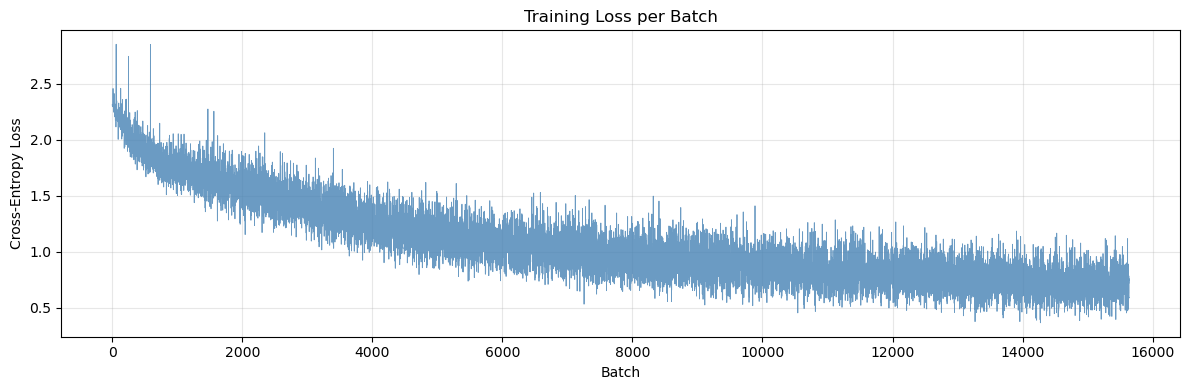

Saved: batch_loss.png


In [17]:
plt.figure(figsize=(12, 4))
plt.plot(batch_losses, linewidth=0.6, alpha=0.8, color='steelblue')
plt.xlabel('Batch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss per Batch')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('batch_loss.png', dpi=150)
plt.show()
print('Saved: batch_loss.png')

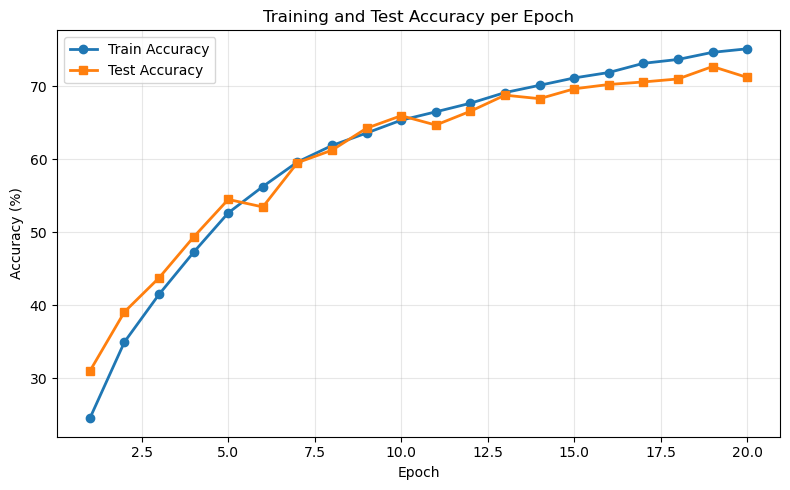

Final train accuracy : 75.12%
Final test accuracy  : 71.20%
Best  test accuracy  : 72.69%
Saved: accuracy.png


In [18]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, [a * 100 for a in train_accuracies],
         label='Train Accuracy', marker='o', linewidth=2)
plt.plot(epochs_range, [a * 100 for a in test_accuracies],
         label='Test Accuracy',  marker='s', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Test Accuracy per Epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy.png', dpi=150)
plt.show()

print(f'Final train accuracy : {train_accuracies[-1]*100:.2f}%')
print(f'Final test accuracy  : {test_accuracies[-1]*100:.2f}%')
print(f'Best  test accuracy  : {max(test_accuracies)*100:.2f}%')
print('Saved: accuracy.png')

In [19]:
# Save model weights — always done AFTER training is complete
torch.save(model.state_dict(), 'baseline_model.pth')
print('Model weights saved to baseline_model.pth')

# Save training statistics as JSON for Person 2
stats = {
    'batch_losses'     : batch_losses,
    'train_accuracies' : train_accuracies,
    'test_accuracies'  : test_accuracies,
    'best_test_acc'    : max(test_accuracies)
}
with open('training_stats.json', 'w') as f:
    json.dump(stats, f)
print('Training statistics saved to training_stats.json')

Model weights saved to baseline_model.pth
Training statistics saved to training_stats.json
